#Data Understanding

In [2]:
from datasets import load_dataset

dataset = load_dataset("PolyAI/minds14", name="en-US")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-US/train-00000-of-00001.parquet:   0%|          | 0.00/34.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/563 [00:00<?, ? examples/s]

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 563
    })
})


In [4]:
print(dataset["train"][0])

{'path': 'en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7f6d0ee09550>, 'transcription': 'I would like to set up a joint account with my partner', 'english_transcription': 'I would like to set up a joint account with my partner', 'intent_class': 11, 'lang_id': 4}


In [5]:
import IPython.display as ipd

sample = dataset["train"][0]

ipd.Audio(sample["audio"]["array"], rate=sample["audio"]["sampling_rate"])

In [6]:
sample = dataset["train"][0]

audio = sample["audio"]

print(audio["array"])
print(audio["sampling_rate"])

[ 0.          0.00024414 -0.00024414 ... -0.00024414  0.
  0.        ]
8000


In [7]:
# mengubah sampling rate menjadi 16000
from datasets import Audio

#dataset_16000 = dataset.cast_column("audio", Audio(sampling_rate=16000))
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

In [8]:
print(dataset["train"][0]["audio"])

In [9]:
print(dataset["train"][0]["audio"]["sampling_rate"])
print("-"*50)
#print(dataset_16000["train"][0]["audio"]["sampling_rate"])

16000
--------------------------------------------------


In [10]:
sample = dataset["train"][0]

print("Text:", sample["transcription"])
print("Sampling rate:", sample["audio"]["sampling_rate"])
print("Array length:", len(sample["audio"]["array"]))

Text: I would like to set up a joint account with my partner
Sampling rate: 16000
Array length: 173398


#EDA (Exploratory Data Analysis)

In [11]:
import numpy as np

durations = [
    len(x["audio"]["array"]) / x["audio"]["sampling_rate"]
    for x in dataset["train"]
]

print("Min duration:", np.min(durations))
print("Max duration:", np.max(durations))
print("Avg duration:", np.mean(durations))

Min duration: 1.706625
Max duration: 58.453375
Avg duration: 8.577395648312612


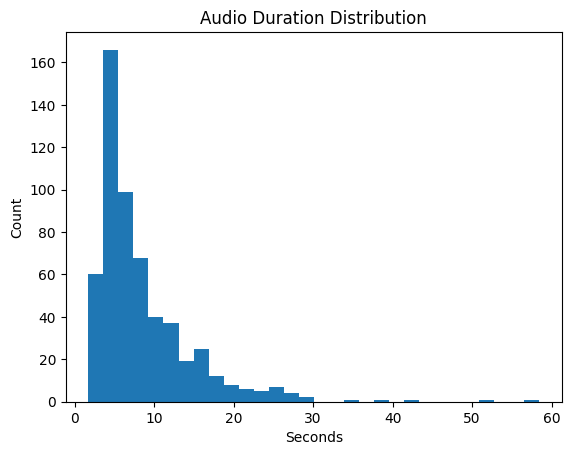

In [12]:
import matplotlib.pyplot as plt

plt.hist(durations, bins=30)
plt.title("Audio Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

In [13]:
#Filter Audio Panjang < 20
dataset = dataset.filter(lambda x: len(x["audio"]["array"]) / 16000 < 20)



Filter:   0%|          | 0/563 [00:00<?, ? examples/s]

In [14]:
import numpy as np

durations = [
    len(x["audio"]["array"]) / x["audio"]["sampling_rate"]
    for x in dataset["train"]
]

print("Min duration:", np.min(durations))
print("Max duration:", np.max(durations))
print("Avg duration:", np.mean(durations))

Min duration: 1.706625
Max duration: 19.87625
Avg duration: 7.491139540337712


In [15]:
text_lengths = [len(x["transcription"]) for x in dataset["train"]]

print("Min text length:", np.min(text_lengths))
print("Max text length:", np.max(text_lengths))
print("Avg text length:", np.mean(text_lengths))

Min text length: 8
Max text length: 250
Avg text length: 64.6547842401501


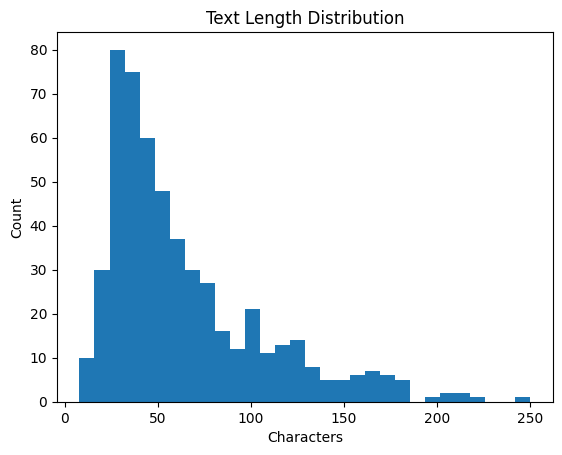

In [16]:
plt.hist(text_lengths, bins=30)
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [17]:
for i in range(5):
    print(dataset["train"][i]["transcription"])

I would like to set up a joint account with my partner
Henry County set up a joint account with my wife and where are they at
how do I start a joint account
can you help me set up a joint bank account
how to set up a joint account


In [18]:
import IPython.display as ipd

sample = dataset["train"][0]

ipd.Audio(sample["audio"]["array"], rate=16000)

#Split DATA TEST-TRAIN-DEV

In [19]:
from datasets import DatasetDict

# =========================
# STEP 1: 80% train, 20% temp
# =========================
split_1 = dataset["train"].train_test_split(
    test_size=0.2,
    seed=42
)

train_dataset = split_1["train"]
temp_dataset = split_1["test"]

# =========================
# STEP 2: split temp jadi dev & test
# =========================
split_2 = temp_dataset.train_test_split(
    test_size=0.5,
    seed=42
)

dev_dataset = split_2["train"]
test_dataset = split_2["test"]

# =========================
# FINAL DATASET
# =========================
final_dataset = DatasetDict({
    "train": train_dataset,
    "validation": dev_dataset,
    "test": test_dataset
})

print(final_dataset)

DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 426
    })
    validation: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 53
    })
    test: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 54
    })
})


In [20]:
print("Train:", len(final_dataset["train"]))
print("Dev:", len(final_dataset["validation"]))
print("Test:", len(final_dataset["test"]))

Train: 426
Dev: 53
Test: 54


#Prerocessing
Konsep Dasar Whisper :
    Audio → Log-Mel Spectrogram → Encoder → Decoder → Text


In [34]:
# 1. Preprocessing (ASR Version)
from transformers import WhisperProcessor

# Processor menggabungkan Feature Extractor (audio) dan Tokenizer (teks)
processor = WhisperProcessor.from_pretrained("openai/whisper-base")

def prepare_dataset_asr(batch):
    # 1. Proses Audio (Input)
    audio = batch["audio"]
    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=16000
    ).input_features[0]

    # 2. Proses Teks (Label/Target)
    # Tokenisasi teks transkripsi menjadi ID label
    batch["labels"] = processor.tokenizer(batch["transcription"]).input_ids
    return batch

# Jalankan mapping
encoded_dataset = final_dataset.map(
    prepare_dataset_asr,
    remove_columns=final_dataset["train"].column_names,
    num_proc=1
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/426 [00:00<?, ? examples/s]

Map:   0%|          | 0/53 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

In [35]:
# Data Collator
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # Padding input audio
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # Padding label teks
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Ganti padding token ID dengan -100 agar tidak dihitung di loss function
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [38]:
pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.3 MB/s eta 0:00:00


In [47]:
# Evaluasi Menggunakan WER
import evaluate

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # Ganti -100 agar bisa di-decode
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer}

In [49]:
# Training Arguments & Model
from transformers import WhisperForConditionalGeneration, TrainingArguments, Trainer, GenerationConfig
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base")

# Buat konfigurasi generasi yang bersih
generation_config = GenerationConfig.from_pretrained("openai/whisper-base")
generation_config.suppress_tokens = []
generation_config.forced_decoder_ids = None

# Masukkan kembali ke model
model.generation_config = generation_config

# Konfigurasi model
#model.config.forced_decoder_ids = None
# model.config.suppress_tokens = []

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/Colab Notebooks/Model/whisper-asr-minds14-01",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    num_train_epochs=5,
    max_steps=-1,
    warmup_steps=500,
    fp16=True,

    # --- PERBAIKAN DI SINI ---
    eval_strategy="epoch",       # Evaluasi setiap akhir epoch agar pasti muncul
    save_strategy="epoch",       # Simpan model setiap akhir epoch
    logging_steps=10,            # Munculkan Training Loss setiap 10 langkah

    predict_with_generate=True,
    generation_max_length=225,
    metric_for_best_model="wer",
    greater_is_better=False,
    report_to="none",

    # Tambahkan ini untuk memastikan log muncul di notebook
    disable_tqdm=False,
    load_best_model_at_end=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
    #tokenizer=processor.feature_extractor,
)

# Cek apakah fungsi evaluasi berjalan sebelum training berat dimulai
print(trainer.evaluate())

trainer.train()

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

{'eval_loss': 5.472581386566162, 'eval_model_preparation_time': 0.0081, 'eval_wer': 57.00483091787439, 'eval_runtime': 13.2923, 'eval_samples_per_second': 3.987, 'eval_steps_per_second': 0.527}


Epoch,Training Loss,Validation Loss,Model Preparation Time,Wer
1,10.639023,5.033237,0.008100,56.843800
2,7.796992,3.659309,0.008100,56.360709
3,5.475905,2.545079,0.008100,55.233494
4,3.604400,1.020417,0.008100,50.885668
5,1.232083,0.526569,0.008100,50.402576


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=135, training_loss=5.96084948292485, metrics={'train_runtime': 518.7254, 'train_samples_per_second': 4.106, 'train_steps_per_second': 0.26, 'total_flos': 1.381517918208e+17, 'train_loss': 5.96084948292485, 'epoch': 5.0})

In [50]:
# Simpan hasil akhir model dan processor agar bisa dipakai lagi nanti
trainer.save_model("/content/drive/MyDrive/Colab Notebooks/Model/whisper-asr-minds14-FINAL")
processor.save_pretrained("/content/drive/MyDrive/Colab Notebooks/Model/whisper-asr-minds14-FINAL")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/Colab Notebooks/Model/whisper-asr-minds14-FINAL/processor_config.json']

In [58]:
# TESTING INFERENCE
# 1. Cara Instan (Hugging Face Pipeline)
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from IPython.display import Audio, display

model_path = "/content/drive/MyDrive/Colab Notebooks/Model/whisper-asr-minds14-FINAL"

# 1. Load Model & Processor
model = WhisperForConditionalGeneration.from_pretrained(model_path).to("cuda")
processor = WhisperProcessor.from_pretrained(model_path)

# 2. Ambil sampel (misalnya indeks ke-0 dari data test)
sample = final_dataset["test"][1]
audio_array = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]

# 3. Tampilkan Pemutar Audio
print("Memutar Audio Asli:")
display(Audio(audio_array, rate=sampling_rate))

# 4. Proses Prediksi (Manual Inference)
input_features = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt").input_features.to("cuda")

with torch.no_grad():
    predicted_ids = model.generate(input_features)

# 5. Decode dan Tampilkan Hasil Teks
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

print(f"\n{'='*30}")
print(f"Hasil Prediksi : {transcription}")
print(f"Teks Sebenarnya: {sample['transcription']}")
print(f"{'='*30}")

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Memutar Audio Asli:



Hasil Prediksi :  Hello, I just wanted to know how much money I currently have in my bank account. Thank you
Teks Sebenarnya: hello I just wanted to know how much money I currently have in my bank account


In [60]:
# 2. Cara Evaluasi Massal (Menguji Seluruh Test Set)
# Jalankan prediksi pada seluruh encoded_test
test_predictions = trainer.predict(encoded_dataset["test"])

# Ambil metriknya (termasuk WER)
print("Metrik pada Test Set:")
print(test_predictions.metrics)

Metrik pada Test Set:
{'test_loss': 0.6787205338478088, 'test_model_preparation_time': 0.0081, 'test_wer': 33.09002433090024, 'test_runtime': 23.9981, 'test_samples_per_second': 2.25, 'test_steps_per_second': 0.292}


In [63]:
# Cara Manual (Input Audio Milik Sendiri)
import torch
import librosa
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from IPython.display import Audio, display

# 1. Path ke model dan file audio Anda
model_path = "/content/drive/MyDrive/Colab Notebooks/Model/whisper-asr-minds14-FINAL"
path_audio_anda = "/content/sample_data/test_02.wav"  # Ganti dengan nama file yang Anda upload

# 2. Load Model & Processor
model = WhisperForConditionalGeneration.from_pretrained(model_path).to("cuda")
processor = WhisperProcessor.from_pretrained(model_path)

# 3. Load dan Resample Audio ke 16kHz
# librosa.load otomatis mengubah audio ke mono dan sampling rate yang kita tentukan
audio_input, sr = librosa.load(path_audio_anda, sr=16000)

# 4. Tampilkan Pemutar Audio untuk verifikasi
print("Mendengarkan file yang diuji:")
display(Audio(audio_input, rate=sr))

# 5. Preprocessing
input_features = processor(audio_input, sampling_rate=sr, return_tensors="pt").input_features.to("cuda")

# 6. Prediksi (Inference)
with torch.no_grad():
    predicted_ids = model.generate(input_features)

# 7. Decode Hasil
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

print(f"\n{'='*40}")
print(f"HASIL TRANSKRIPSI: {transcription}")
print(f"{'='*40}")

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Mendengarkan file yang diuji:



HASIL TRANSKRIPSI:  it's so hard to see how it works
